# Posterior-weighted 2D regression

`weighted_regression_2d` fits a straight, constant-velocity trajectory to a
posterior probability array with shape `(x, y, time)`. It returns
`r2, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y`.

The fit minimizes posterior-weighted squared Euclidean residuals:
$\hat{\mathbf p}(t)=\bar{\mathbf p}+\mathbf b(t-\bar t)$.
The variance-weighted multivariate coefficient of determination is

$$R^2=1-\frac{\mathrm{SSE}}{\mathrm{SST}}
=\frac{\operatorname{Cov}_w(X,T)^2+\operatorname{Cov}_w(Y,T)^2}
{\operatorname{Var}_w(T)[\operatorname{Var}_w(X)+\operatorname{Var}_w(Y)]}.$$

**The first returned value is R²**, the fraction of total spatial variance
explained by the fitted line, in [0,1]. It is unsigned. Slopes encode direction;
the last two outputs are spatial means, not regression intercepts.
The fitted trajectory is distinct from the posterior center of mass.

Use the same physical units for x and y for rotation invariance. Normalize
each time slice to one for equal temporal weighting. Synthetic examples below
need no external data; the final real-data workflow is optional.


In [1]:
import matplotlib
import matplotlib.cm as mpl_cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import nelpy as nel
import numpy as np
import pandas as pd

import neuro_py as npy
from neuro_py.ensemble.replay import weighted_regression_2d

## R² magnitude and shuffle significance

R² describes explained spatial variance; its size alone does not establish
whether an event is unusual under a null model. A diffuse linear posterior
can explain little total variance yet have more temporal structure than its
shuffles. Each simulation below includes an observed-versus-null histogram.

The self-contained helper reproduces `hpc_ctx.replay.replay_2d`'s
`axis_wise_toroidal` method: independently translate each spatial posterior
by random x/y offsets, wrapping at the arena boundaries. This preserves
per-bin probability values, total mass, and shape on the torus while
disrupting the spatial alignment between time bins.

We use **500 shuffles** and a fixed seed. The upper-tail Monte Carlo p-value
is `(1 + number of shuffled R² >= observed R²) / (1 + n_shuffles)`, including
ties. Its minimum is 1/501 (approximately 0.002). The dashed line marks the
null 95th percentile; p-values provide the decision rule at the chosen alpha.

These are illustrative, unadjusted per-simulation p-values under this
specific null, not proof of biological replay. Toroidal shifts assume a
wraparound geometry, and independent bin shifts remove temporal dependence.
Real arena boundaries and overlapping decode windows still require separate
null calibration. The simulated posteriors here do not use overlapping spike
count windows.


In [2]:
N_SHUFFLES = 500
SHUFFLE_SEED = 42


def toroidal_spatial_shuffle(posterior, x_shifts, y_shifts):
    """Translate each spatial posterior independently on a 2D torus."""
    shuffled = np.empty_like(posterior)
    for k in range(posterior.shape[2]):
        shuffled[:, :, k] = np.roll(
            posterior[:, :, k], shift=(x_shifts[k], y_shifts[k]), axis=(0, 1)
        )
    return shuffled


def r2_shuffle_test(posterior, n_shuffles=N_SHUFFLES, seed=SHUFFLE_SEED):
    """Return observed R², the spatial null, and its upper-tail Monte Carlo p."""
    if not isinstance(n_shuffles, (int, np.integer)) or n_shuffles < 1:
        raise ValueError("n_shuffles must be a positive integer")
    observed = weighted_regression_2d(posterior)[0]
    rng = np.random.default_rng(seed)
    nx, ny, nt = posterior.shape
    null = np.empty(n_shuffles)
    for b in range(n_shuffles):
        x_shifts = rng.integers(0, nx, size=nt)
        y_shifts = rng.integers(0, ny, size=nt)
        null[b] = weighted_regression_2d(
            toroidal_spatial_shuffle(posterior, x_shifts, y_shifts)
        )[0]
    if not np.isfinite(observed) or not np.all(np.isfinite(null)):
        raise ValueError("Observed and shuffled R² must be finite for this test")
    p_value = (1 + np.count_nonzero(null >= observed)) / (n_shuffles + 1)
    return observed, null, p_value


def plot_r2_nulls(simulations, n_shuffles=N_SHUFFLES, seed=SHUFFLE_SEED):
    """Plot each simulation against its null and return a numeric summary."""
    ncols = min(3, len(simulations))
    nrows = (len(simulations) + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.3 * ncols, 3.2 * nrows),
        squeeze=False,
        constrained_layout=True,
    )
    streams = np.random.SeedSequence(seed).spawn(len(simulations))
    rows = []
    for ax, (name, posterior), stream in zip(axes.flat, simulations.items(), streams):
        observed, null, p_value = r2_shuffle_test(posterior, n_shuffles, stream)
        q95 = np.quantile(null, 0.95)
        ax.hist(
            null, bins=30, color="steelblue", alpha=0.8, label="Toroidal spatial null"
        )
        ax.axvline(q95, color="0.25", ls="--", lw=1.4, label="Null 95th percentile")
        ax.axvline(observed, color="crimson", lw=2, label="Observed R²")
        ax.set(
            title=f"{name}\nR² = {observed:.4f}; p = {p_value:.4f}",
            xlabel="R²",
            ylabel="Shuffle count",
            xlim=(0, max(0.01, max(observed, null.max()) * 1.06)),
        )
        ax.legend(fontsize=7)
        rows.append(
            {
                "simulation": name,
                "observed_r2": observed,
                "null_95th_percentile": q95,
                "p_value": p_value,
                "n_shuffles": n_shuffles,
            }
        )
    for ax in axes.flat[len(simulations) :]:
        ax.set_visible(False)
    plt.show()
    return pd.DataFrame(rows).set_index("simulation")

## Straight trajectories in different directions

A perfectly localized, constant-velocity trajectory has R² = 1 in every direction.


,R²,slope_x,slope_y
trajectory,,,
Diagonal,1.0,1.0,1.0
Anti-diagonal,1.0,1.0,-1.0
Reverse diagonal,1.0,-1.0,-1.0


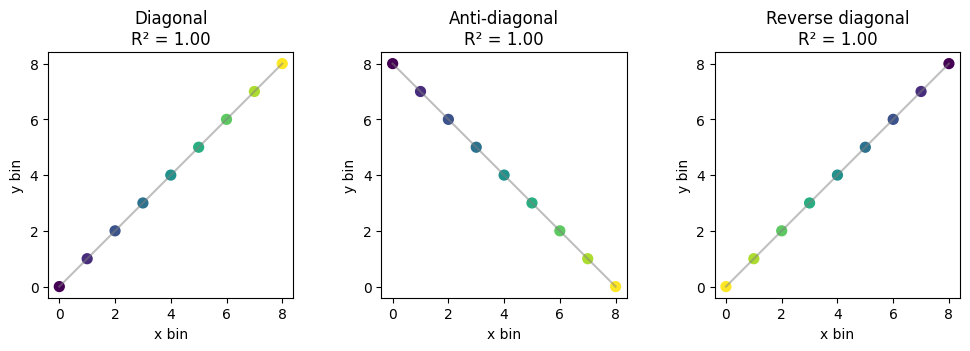

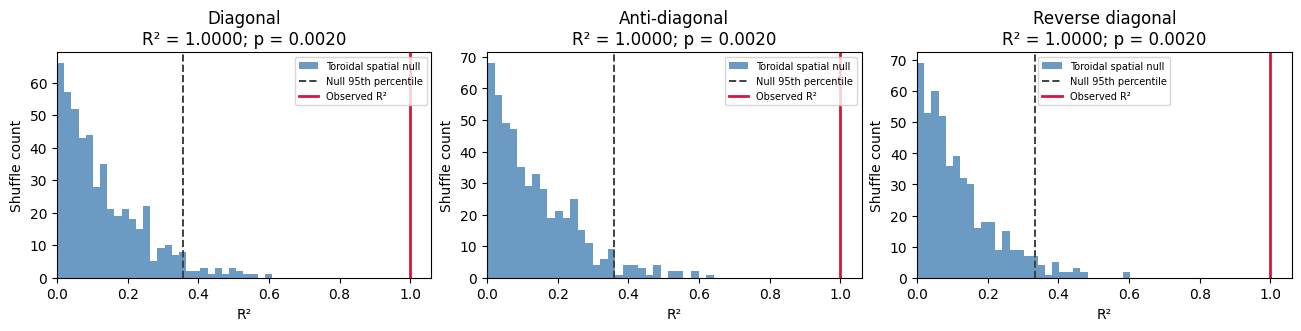

,observed_r2,null_95th_percentile,p_value,n_shuffles
simulation,,,,
Diagonal,1.0,0.358077,0.001996,500
Anti-diagonal,1.0,0.360742,0.001996,500
Reverse diagonal,1.0,0.332554,0.001996,500


In [3]:
n = 9
diagonal = np.zeros((n, n, n))
diagonal[np.arange(n), np.arange(n), np.arange(n)] = 1
examples = {
    "Diagonal": diagonal,
    "Anti-diagonal": diagonal[:, ::-1, :],
    "Reverse diagonal": diagonal[..., ::-1],
}
rows = []
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), constrained_layout=True)
for ax, (name, posterior) in zip(axes, examples.items()):
    r2, x_fit, y_fit, vx, vy, mx, my = weighted_regression_2d(posterior)
    rows.append({"trajectory": name, "R²": r2, "slope_x": vx, "slope_y": vy})
    np.testing.assert_allclose(r2, 1, atol=1e-12)
    ax.scatter(x_fit, y_fit, c=np.arange(n), cmap="viridis", s=50)
    ax.plot(x_fit, y_fit, color="0.5", alpha=0.5)
    ax.set(title=f"{name}\nR² = {r2:.2f}", xlabel="x bin", ylabel="y bin")
    ax.set_aspect("equal")
display(pd.DataFrame(rows).set_index("trajectory"))
plt.show()

display(plot_r2_nulls(examples))

### Equal-speed trajectories with identical uncertainty

Horizontal velocity (5,0) and oblique velocity (3,4) have equal magnitude.
Both posteriors have the same symmetric isotropic uncertainty and avoid arena
boundaries. Integer coordinates eliminate interpolation artifacts. Reflecting
the oblique trajectory additionally tests opposing directions.

,R²
trajectory,
Horizontal,0.98903
Oblique,0.98903
Reflected oblique,0.98903


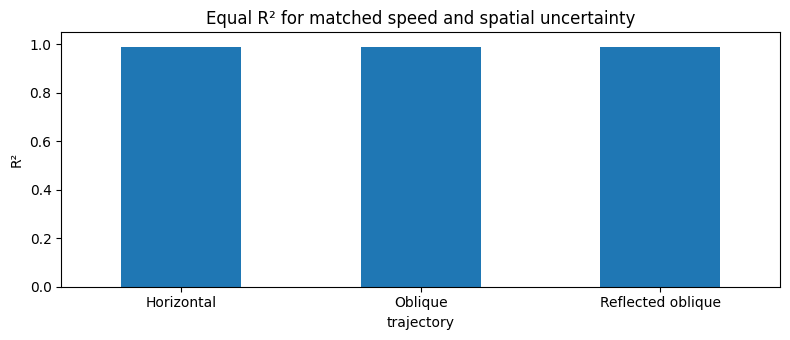

,spread,R²
0,0.3,0.999908
1,1.0,0.989030
2,2.0,0.980429


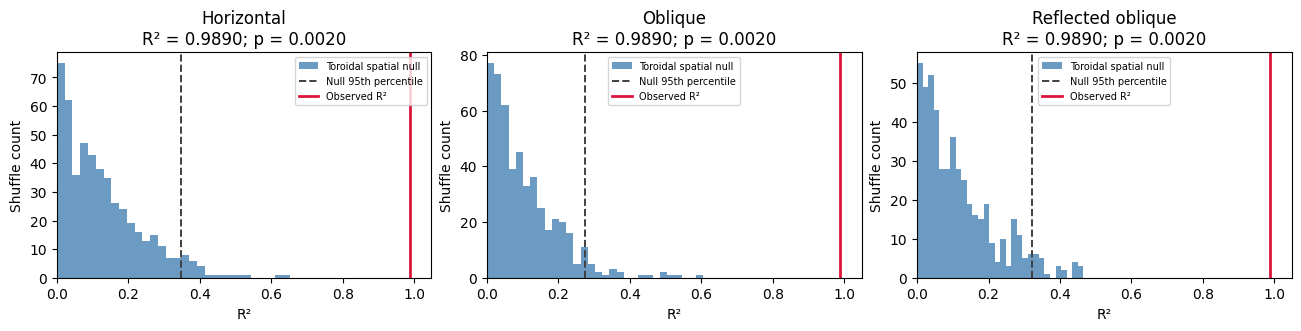

,observed_r2,null_95th_percentile,p_value,n_shuffles
simulation,,,,
Horizontal,0.98903,0.348691,0.001996,500
Oblique,0.98903,0.272963,0.001996,500
Reflected oblique,0.98903,0.322592,0.001996,500


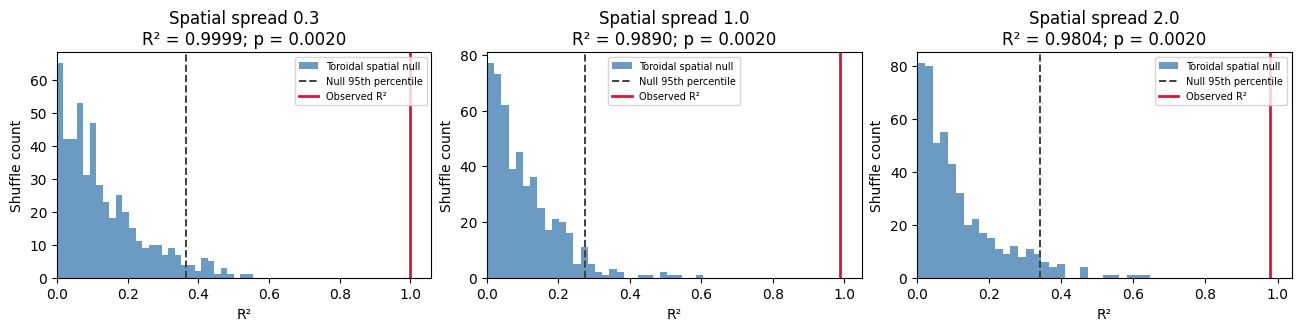

,observed_r2,null_95th_percentile,p_value,n_shuffles
simulation,,,,
Spatial spread 0.3,0.999908,0.364154,0.001996,500
Spatial spread 1.0,0.989030,0.272963,0.001996,500
Spatial spread 2.0,0.980429,0.341145,0.001996,500


In [4]:
def equal_speed_posterior(dx, dy, spread=1):
    posterior = np.zeros((65, 65, 9))
    offsets = np.arange(-2, 3)
    mass = np.exp(-(offsets**2) / (2 * spread**2))
    mass /= mass.sum()
    for k in range(9):
        posterior[np.ix_(10 + dx * k + offsets, 10 + dy * k + offsets, [k])] = (
            mass[:, None] * mass[None, :]
        )[..., None]
    return posterior


horizontal = equal_speed_posterior(5, 0)
oblique = equal_speed_posterior(3, 4)
matched = {
    "Horizontal": horizontal,
    "Oblique": oblique,
    "Reflected oblique": oblique[:, ::-1],
}
rotation_table = pd.DataFrame(
    [
        {"trajectory": name, "R²": weighted_regression_2d(p)[0]}
        for name, p in matched.items()
    ]
).set_index("trajectory")
np.testing.assert_allclose(
    rotation_table["R²"], rotation_table["R²"].iloc[0], atol=1e-12
)
display(rotation_table)
rotation_table.plot.bar(
    rot=0, ylim=(0, 1.05), ylabel="R²", figsize=(8, 3.5), legend=False
)
plt.title("Equal R² for matched speed and spatial uncertainty")
plt.tight_layout()
plt.show()

# Posterior spread is retained in the residual, unlike scoring only its mean.
uncertainty = pd.DataFrame(
    [
        {
            "spread": spread,
            "R²": weighted_regression_2d(equal_speed_posterior(3, 4, spread))[0],
        }
        for spread in (0.3, 1.0, 2.0)
    ]
)
assert np.all(np.diff(uncertainty["R²"]) < 0)
display(uncertainty)

display(plot_r2_nulls(matched))
display(
    plot_r2_nulls(
        {
            f"Spatial spread {spread}": equal_speed_posterior(3, 4, spread)
            for spread in (0.3, 1.0, 2.0)
        }
    )
)

## Helper: Simulation Functions

Each helper normalizes every spatial slice to sum to one. Decode bins
therefore have equal total weight, including near arena boundaries.


In [5]:
def simulate_degenerate_x(t_dim=20, x_fixed=5, noise=0.01):
    """All weight on a single x row — trajectory moves only in Y."""
    rng = np.random.default_rng(42)
    x_dim, y_dim = 10, 10
    weights = np.zeros((x_dim, y_dim, t_dim), dtype=np.float64)
    for k in range(t_dim):
        cy = k / (t_dim - 1) * (y_dim - 1)
        for j in range(y_dim):
            weights[x_fixed, j, k] = np.exp(-((j - cy) ** 2) / 4.0)
    weights[x_fixed] += rng.uniform(0, noise, (y_dim, t_dim))
    return weights / weights.sum(axis=(0, 1), keepdims=True)


def simulate_degenerate_y(t_dim=20, y_fixed=5, noise=0.01):
    """All weight on a single y column — trajectory moves only in X."""
    rng = np.random.default_rng(42)
    x_dim, y_dim = 10, 10
    weights = np.zeros((x_dim, y_dim, t_dim), dtype=np.float64)
    for k in range(t_dim):
        cx = k / (t_dim - 1) * (x_dim - 1)
        for i in range(x_dim):
            weights[i, y_fixed, k] = np.exp(-((i - cx) ** 2) / 4.0)
    weights[:, y_fixed, :] += rng.uniform(0, noise, (x_dim, t_dim))
    return weights / weights.sum(axis=(0, 1), keepdims=True)


def simulate_no_movement(t_dim=20, noise=0.01):
    """Weight fixed at a single spatial location — no temporal drift."""
    rng = np.random.default_rng(42)
    x_dim, y_dim = 10, 10
    weights = np.zeros((x_dim, y_dim, t_dim), dtype=np.float64)
    weights[5, 5, :] = 1.0
    weights += rng.uniform(0, noise, (x_dim, y_dim, t_dim))
    return weights / weights.sum(axis=(0, 1), keepdims=True)


def simulate_both_axes(t_dim=20, noise=0.01):
    """Weight drifts diagonally — both X and Y move over time."""
    rng = np.random.default_rng(42)
    x_dim, y_dim = 10, 10
    weights = np.zeros((x_dim, y_dim, t_dim), dtype=np.float64)
    for k in range(t_dim):
        cx = k / (t_dim - 1) * (x_dim - 1)
        cy = k / (t_dim - 1) * (y_dim - 1)
        for i in range(x_dim):
            for j in range(y_dim):
                weights[i, j, k] = np.exp(-((i - cx) ** 2 + (j - cy) ** 2) / 4.0)
    weights += rng.uniform(0, noise, weights.shape)
    return weights / weights.sum(axis=(0, 1), keepdims=True)


def simulate_anti_diagonal(t_dim=20, noise=0.01):
    """Weight drifts along an anti-diagonal — both X and Y move over time."""
    rng = np.random.default_rng(42)
    x_dim, y_dim = 10, 10
    weights = np.zeros((x_dim, y_dim, t_dim), dtype=np.float64)
    for k in range(t_dim):
        cx = k / (t_dim - 1) * (x_dim - 1)
        cy = (y_dim - 1) - k / (t_dim - 1) * (y_dim - 1)
        for i in range(x_dim):
            for j in range(y_dim):
                weights[i, j, k] = np.exp(-((i - cx) ** 2 + (j - cy) ** 2) / 4.0)
    weights += rng.uniform(0, noise, weights.shape)
    return weights / weights.sum(axis=(0, 1), keepdims=True)


def simulate_curved(t_dim=20, noise=0.05):
    """Trajectory follows a curved arc (sine wave in Y)."""
    rng = np.random.default_rng(42)
    x_dim, y_dim = 10, 10
    weights = np.zeros((x_dim, y_dim, t_dim), dtype=np.float64)
    for k in range(t_dim):
        cx = k / (t_dim - 1) * (x_dim - 1)
        cy = 4.5 + 4.0 * np.sin(np.pi * k / (t_dim - 1))  # arc from 4.5 -> peak -> 4.5
        for i in range(x_dim):
            for j in range(y_dim):
                weights[i, j, k] = np.exp(-((i - cx) ** 2 + (j - cy) ** 2) / 2.0)
    weights += rng.uniform(0, noise, weights.shape)
    return weights / weights.sum(axis=(0, 1), keepdims=True)


def simulate_noisy_linear(t_dim=20, noise=0.15):
    """Linear trajectory with substantial noise — realistic decode uncertainty."""
    rng = np.random.default_rng(42)
    x_dim, y_dim = 10, 10
    weights = np.zeros((x_dim, y_dim, t_dim), dtype=np.float64)
    for k in range(t_dim):
        cx = k / (t_dim - 1) * (x_dim - 1)
        cy = k / (t_dim - 1) * (y_dim - 1)
        for i in range(x_dim):
            for j in range(y_dim):
                weights[i, j, k] = np.exp(-((i - cx) ** 2 + (j - cy) ** 2) / 4.0)
    weights += rng.uniform(0, noise, weights.shape)
    return weights / weights.sum(axis=(0, 1), keepdims=True)


def simulate_reverse(t_dim=20, noise=0.01):
    """Trajectory moves from high to low — tests signed slopes with unsigned R²."""
    rng = np.random.default_rng(42)
    x_dim, y_dim = 10, 10
    weights = np.zeros((x_dim, y_dim, t_dim), dtype=np.float64)
    for k in range(t_dim):
        cx = (x_dim - 1) - k / (t_dim - 1) * (x_dim - 1)  # 9 -> 0
        cy = (y_dim - 1) - k / (t_dim - 1) * (y_dim - 1)  # 9 -> 0
        for i in range(x_dim):
            for j in range(y_dim):
                weights[i, j, k] = np.exp(-((i - cx) ** 2 + (j - cy) ** 2) / 4.0)
    weights += rng.uniform(0, noise, weights.shape)
    return weights / weights.sum(axis=(0, 1), keepdims=True)


def simulate_fragmented(t_dim=20, noise=0.05):
    """Weight jumps between two spatial clusters — fragmented/ambiguous replay."""
    rng = np.random.default_rng(42)
    x_dim, y_dim = 10, 10
    weights = np.zeros((x_dim, y_dim, t_dim), dtype=np.float64)
    for k in range(t_dim):
        # Alternate between two clusters
        if k % 4 < 2:
            cx, cy = 2.0, 2.0
        else:
            cx, cy = 7.0, 7.0
        for i in range(x_dim):
            for j in range(y_dim):
                weights[i, j, k] = np.exp(-((i - cx) ** 2 + (j - cy) ** 2) / 2.0)
    weights += rng.uniform(0, noise, weights.shape)
    return weights / weights.sum(axis=(0, 1), keepdims=True)


def helper_plot(weights):
    fig, ax = plt.subplots(1, weights.shape[2], figsize=(20, 2))
    vmax = np.percentile(weights, 99.9)
    for i in range(weights.shape[2]):
        ax[i].imshow(
            weights[..., i].T, origin="lower", aspect="equal", vmin=0, vmax=vmax
        )
        ax[i].set_title(f"t={i}")
    plt.show()

## Section 1 — Degenerate Cases

These scenarios test the edge cases where movement is confined to a single axis or absent entirely.

### 1a. Only Y-axis movement (degenerate X)

R²   : 0.7545
slope_x             : -4.474e-17  (expect ~0)
slope_y             : 0.4099


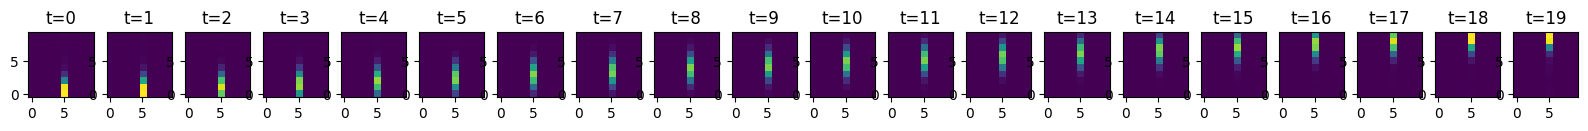

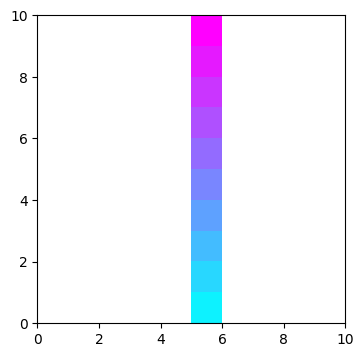

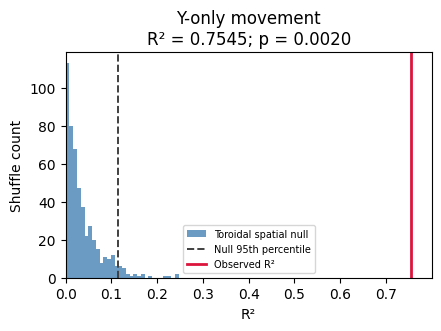

,observed_r2,null_95th_percentile,p_value,n_shuffles
simulation,,,,
Y-only movement,0.754473,0.114447,0.001996,500


In [6]:
weights = simulate_degenerate_x()
r2, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_regression_2d(weights)

print(f"R²   : {r2:.4f}")
print(f"slope_x             : {slope_x:.3e}  (expect ~0)")
print(f"slope_y             : {slope_y:.4f}")

helper_plot(weights)
npy.plotting.plot_2d_replay(weights)
plt.show()

null_summary = plot_r2_nulls({"Y-only movement": weights})
display(null_summary)

### 1b. Only X-axis movement (degenerate Y)

R²   : 0.7545
slope_x             : 0.4099
slope_y             : -4.474e-17  (expect ~0)


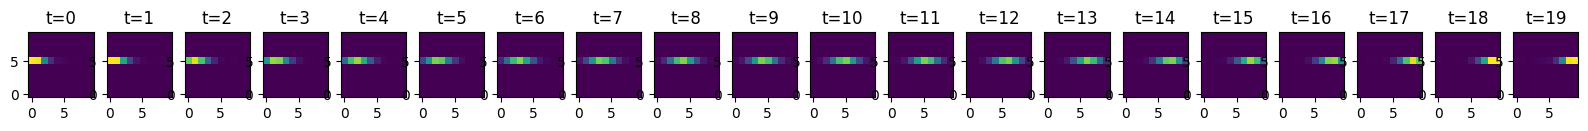

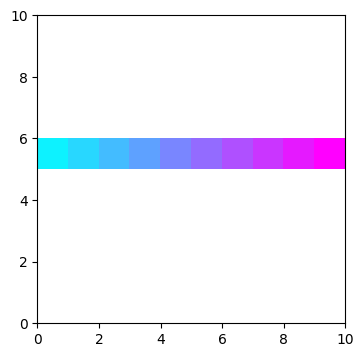

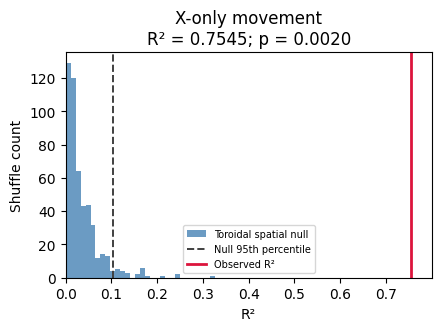

,observed_r2,null_95th_percentile,p_value,n_shuffles
simulation,,,,
X-only movement,0.754473,0.10342,0.001996,500


In [7]:
weights = simulate_degenerate_y()
r2, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_regression_2d(weights)

print(f"R²   : {r2:.4f}")
print(f"slope_x             : {slope_x:.4f}")
print(f"slope_y             : {slope_y:.3e}  (expect ~0)")
helper_plot(weights)

npy.plotting.plot_2d_replay(weights)
plt.show()

null_summary = plot_r2_nulls({"X-only movement": weights})
display(null_summary)

### 1c. No movement (neither axis)

R²   : 0.0001  (expect ~0, no signal)
slope_x             : 3.815e-03
slope_y             : 1.324e-03


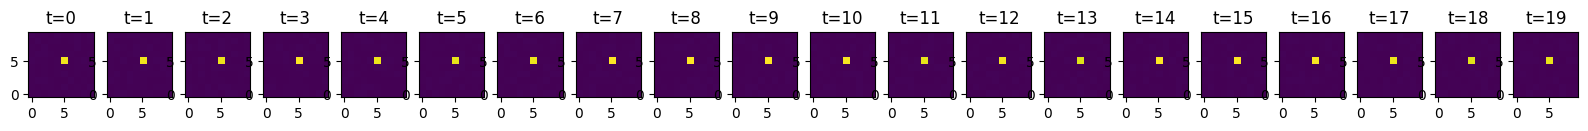

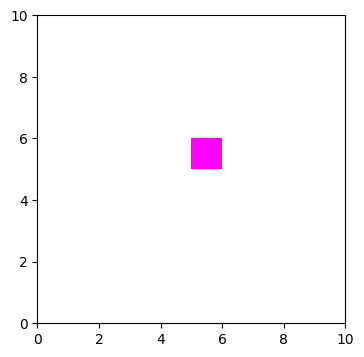

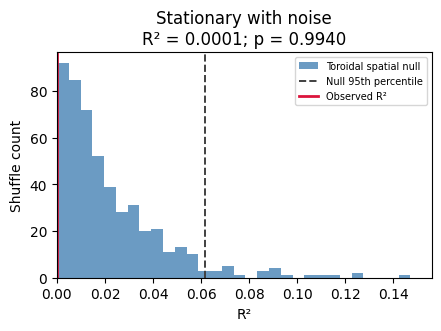

,observed_r2,null_95th_percentile,p_value,n_shuffles
simulation,,,,
Stationary with noise,0.000096,0.061809,0.994012,500


In [8]:
weights = simulate_no_movement()
r2, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_regression_2d(weights)

print(f"R²   : {r2:.4f}  (expect ~0, no signal)")
print(f"slope_x             : {slope_x:.3e}")
print(f"slope_y             : {slope_y:.3e}")

helper_plot(weights)
npy.plotting.plot_2d_replay(weights)
plt.show()

null_summary = plot_r2_nulls({"Stationary with noise": weights})
display(null_summary)

### 1d. Both axes moving (diagonal)

R²   : 0.6926
slope_x             : 0.3924
slope_y             : 0.3921


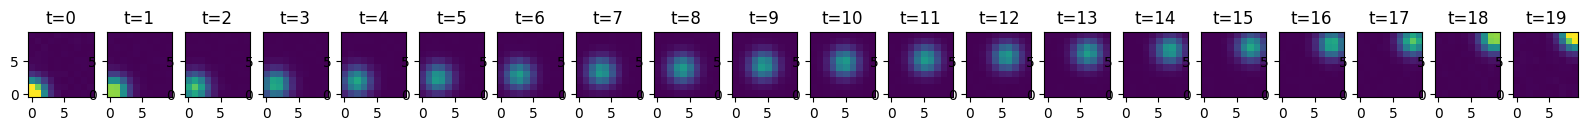

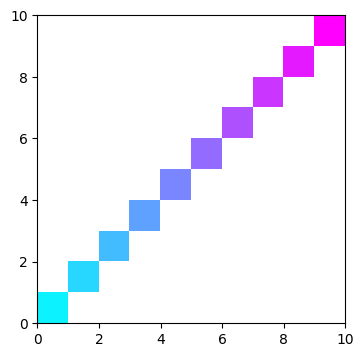

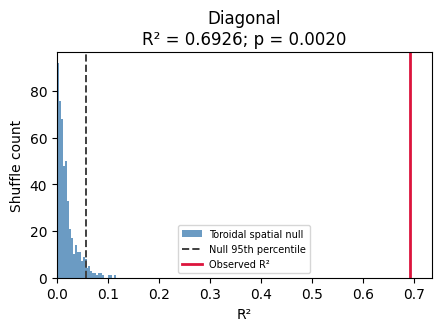

,observed_r2,null_95th_percentile,p_value,n_shuffles
simulation,,,,
Diagonal,0.692552,0.057315,0.001996,500


In [9]:
weights = simulate_both_axes()
r2, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_regression_2d(weights)

print(f"R²   : {r2:.4f}")
print(f"slope_x             : {slope_x:.4f}")
print(f"slope_y             : {slope_y:.4f}")

helper_plot(weights)
npy.plotting.plot_2d_replay(weights)
plt.show()

null_summary = plot_r2_nulls({"Diagonal": weights})
display(null_summary)

#### Anti-diagonal trajectory

X increases while Y decreases. R² describes explained spatial variance; slopes describe the direction.


R² : 0.6913
slope_x          : 0.3924
slope_y          : -0.3914


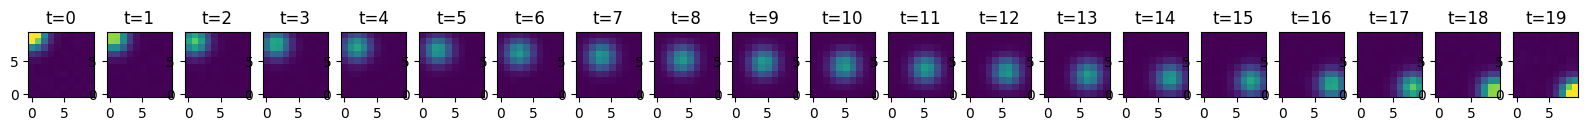

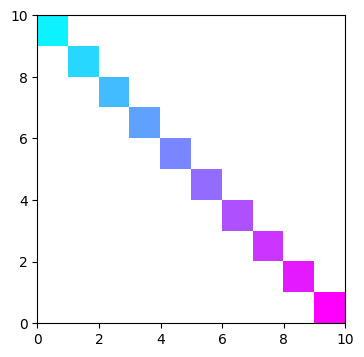

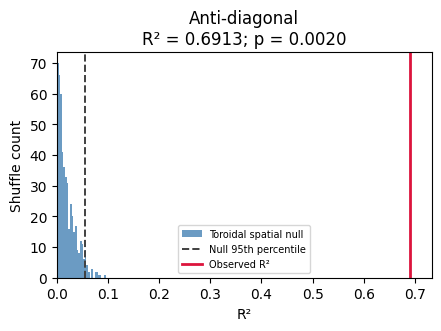

,observed_r2,null_95th_percentile,p_value,n_shuffles
simulation,,,,
Anti-diagonal,0.691281,0.054067,0.001996,500


In [10]:
weights = simulate_anti_diagonal()
r2, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_regression_2d(weights)
print(f"R² : {r2:.4f}")
print(f"slope_x          : {slope_x:.4f}")
print(f"slope_y          : {slope_y:.4f}")
helper_plot(weights)
npy.plotting.plot_2d_replay(weights)
plt.show()

null_summary = plot_r2_nulls({"Anti-diagonal": weights})
display(null_summary)

#### Perfect anti-diagonal

This localized linear trajectory has R² = 1, with slopes +1 and −1.


R² : 1.0000 (expect 1.0000)
slope_x          : 1.0000 (expect +1.0000)
slope_y          : -1.0000 (expect -1.0000)


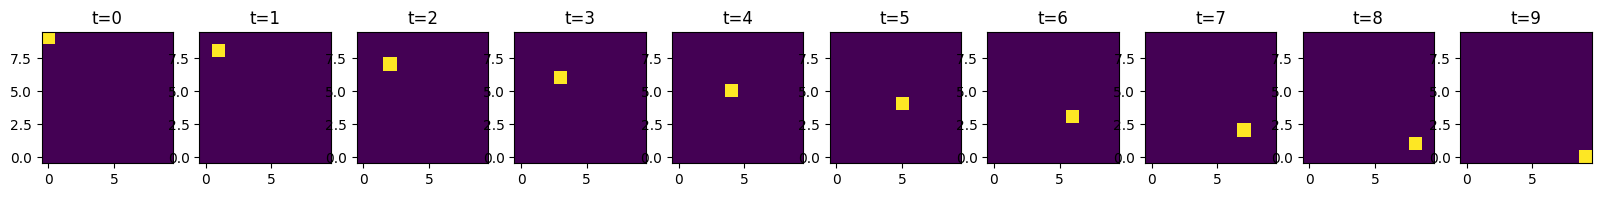

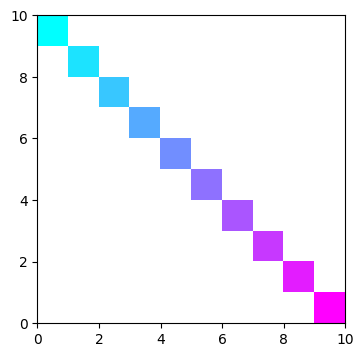

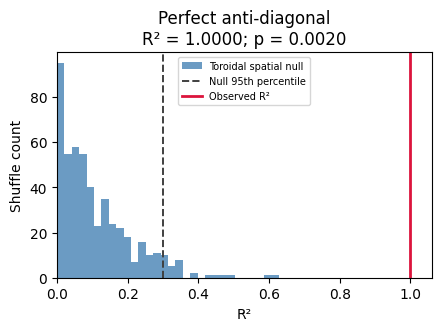

,observed_r2,null_95th_percentile,p_value,n_shuffles
simulation,,,,
Perfect anti-diagonal,1.0,0.301341,0.001996,500


In [11]:
n = 10
weights = np.zeros((n, n, n), dtype=np.float64)
for t in range(n):
    weights[t, n - 1 - t, t] = 1.0
r2, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_regression_2d(weights)
print(f"R² : {r2:.4f} (expect 1.0000)")
print(f"slope_x          : {slope_x:.4f} (expect +1.0000)")
print(f"slope_y          : {slope_y:.4f} (expect -1.0000)")
np.testing.assert_allclose(r2, 1.0, atol=1e-12)
helper_plot(weights)
npy.plotting.plot_2d_replay(weights)
plt.show()

display(plot_r2_nulls({"Perfect anti-diagonal": weights}))

## Section 2 — Realistic Scenarios

Real decoded posteriors are rarely perfectly linear — they contain noise, curvature, and ambiguity. These scenarios test how `weighted_regression_2d` behaves under more naturalistic conditions.

### 2a. Curved trajectory (sine arc)

The center of mass follows a smooth arc in Y while sweeping across X. Since `weighted_regression_2d` fits a **linear** model, the R² will be attenuated relative to a straight-line trajectory — the function captures the dominant linear trend.

R²   : 0.2398  (attenuated vs diagonal — nonlinear Y)
slope_x             : 0.3072  (X is still linear)
slope_y             : 0.0012  (near 0 — arc cancels out)


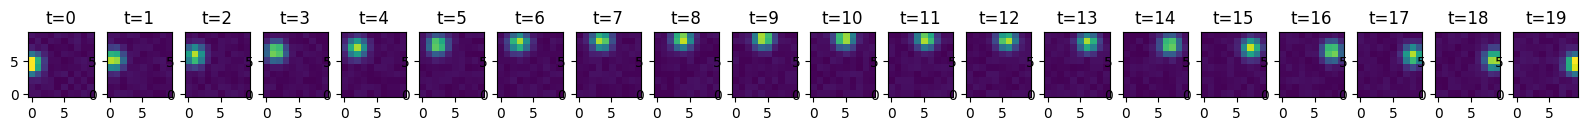

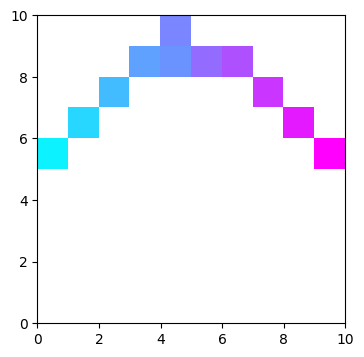

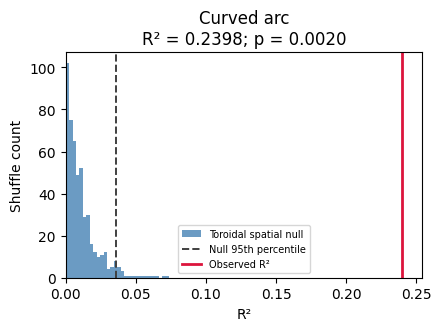

,observed_r2,null_95th_percentile,p_value,n_shuffles
simulation,,,,
Curved arc,0.239764,0.035767,0.001996,500


In [12]:
weights = simulate_curved()
r2, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_regression_2d(weights)

print(f"R²   : {r2:.4f}  (attenuated vs diagonal — nonlinear Y)")
print(f"slope_x             : {slope_x:.4f}  (X is still linear)")
print(f"slope_y             : {slope_y:.4f}  (near 0 — arc cancels out)")

helper_plot(weights)
npy.plotting.plot_2d_replay(weights)
plt.show()

null_summary = plot_r2_nulls({"Curved arc": weights})
display(null_summary)

### 2b. Noisy linear trajectory

A diagonal trajectory with substantial decode uncertainty. This is the most common real-data scenario — the signal is present but diluted by diffuse posteriors.

The histogram below separates fit magnitude from evidence against the
spatial null. A small R² is not automatically nonsignificant. Read the
computed p-value for this particular simulation rather than applying a
universal R² cutoff; low R² still indicates substantial unexplained variance.


R²   : 0.0517  (lower than clean diagonal due to noise)
slope_x             : 0.1127
slope_y             : 0.1076


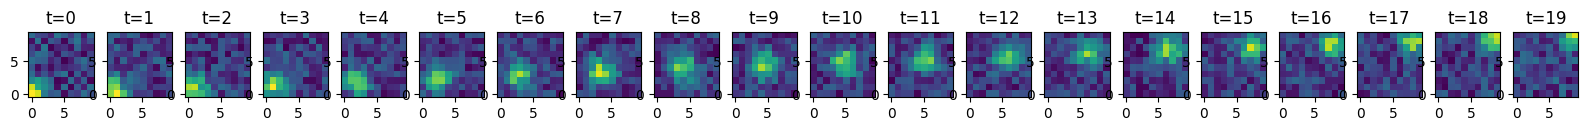

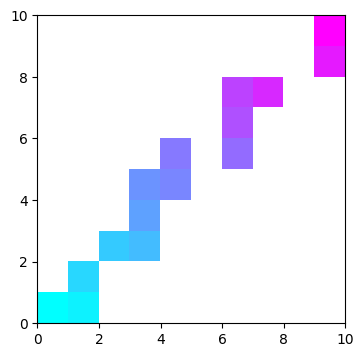

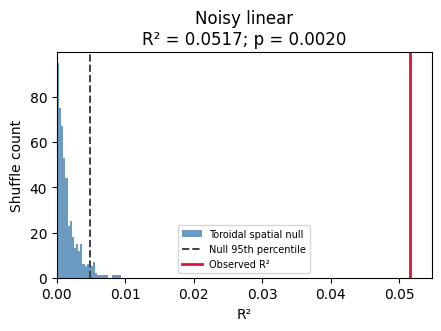

,observed_r2,null_95th_percentile,p_value,n_shuffles
simulation,,,,
Noisy linear,0.051652,0.004804,0.001996,500


In [13]:
weights = simulate_noisy_linear(noise=0.50)
r2, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_regression_2d(weights)

print(f"R²   : {r2:.4f}  (lower than clean diagonal due to noise)")
print(f"slope_x             : {slope_x:.4f}")
print(f"slope_y             : {slope_y:.4f}")

helper_plot(weights)
npy.plotting.plot_2d_replay(weights)
plt.show()

null_summary = plot_r2_nulls({"Noisy linear": weights})
display(null_summary)

### 2c. Reverse trajectory

Reversing time preserves unsigned R² and reverses the signed
slopes. Forward/reverse relative to behavior requires a behavioral reference.


R²   : 0.6890  (unsigned strength; direction is in slopes)
slope_x             : -0.3911  (negative slope)
slope_y             : -0.3914  (negative slope)


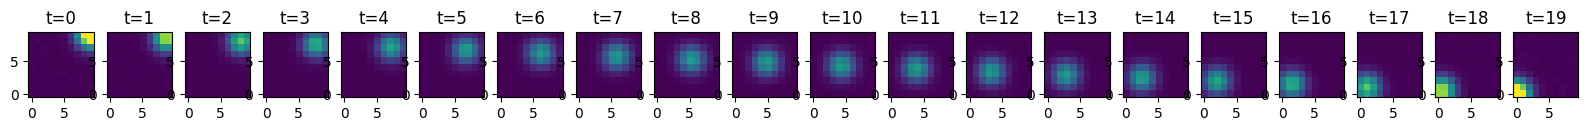

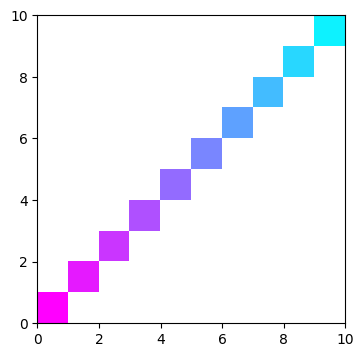

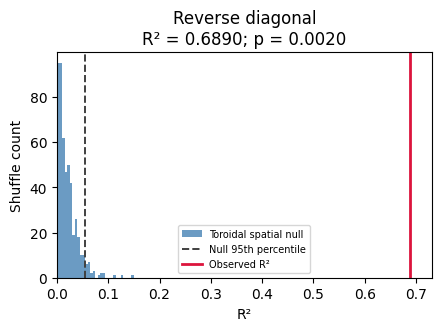

,observed_r2,null_95th_percentile,p_value,n_shuffles
simulation,,,,
Reverse diagonal,0.689025,0.055623,0.001996,500


In [14]:
weights = simulate_reverse()
r2, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_regression_2d(weights)

print(f"R²   : {r2:.4f}  (unsigned strength; direction is in slopes)")
print(f"slope_x             : {slope_x:.4f}  (negative slope)")
print(f"slope_y             : {slope_y:.4f}  (negative slope)")

helper_plot(weights)
npy.plotting.plot_2d_replay(weights)
plt.show()

null_summary = plot_r2_nulls({"Reverse diagonal": weights})
display(null_summary)

### 2d. Fragmented replay

The posterior alternates between two distant spatial clusters. This example
has low R² because repeated back-and-forth jumps produce little net linear
progression, even though probability is spatially concentrated. Other
discontinuous paths can have substantial R²; fit quality alone does not
establish continuity.


R²   : 0.0135  (linear fit across two clusters)
slope_x             : 0.0561
slope_y             : 0.0539


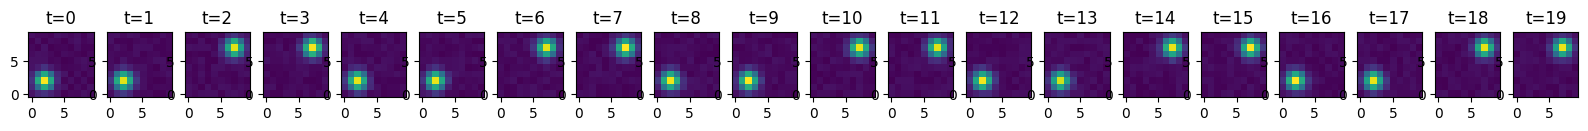

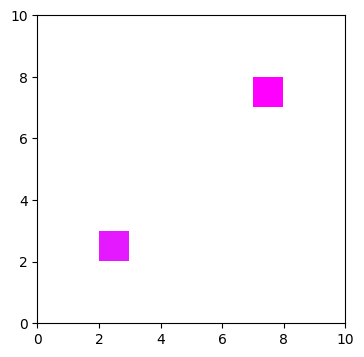

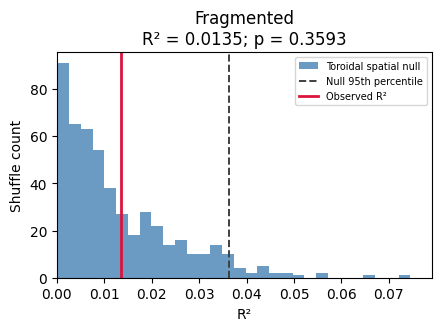

,observed_r2,null_95th_percentile,p_value,n_shuffles
simulation,,,,
Fragmented,0.013464,0.036332,0.359281,500


In [15]:
weights = simulate_fragmented()
r2, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_regression_2d(weights)

print(f"R²   : {r2:.4f}  (linear fit across two clusters)")
print(f"slope_x             : {slope_x:.4f}")
print(f"slope_y             : {slope_y:.4f}")

helper_plot(weights)
npy.plotting.plot_2d_replay(weights)
plt.show()

null_summary = plot_r2_nulls({"Fragmented": weights})
display(null_summary)

## Warmed-up performance

The Numba kernel scans the posterior once, uses float64 accumulators,
and allocates only small marginal arrays. It releases the GIL and avoids
per-event parallel dispatch. Timing excludes first-call JIT compilation and
includes the public wrapper and trajectory outputs. Measurements below are
machine-specific, not an end-to-end replay runtime guarantee.

In [16]:
import timeit

benchmark_rows = []
for dtype in (np.float32, np.float64):
    for layout in ("C", "F"):
        p = np.random.default_rng(42).random((50, 50, 20)).astype(dtype)
        p /= p.sum(axis=(0, 1), keepdims=True)
        p = np.array(p, order=layout)
        weighted_regression_2d(p)  # compile/warm up this signature
        seconds = (
            min(timeit.repeat(lambda: weighted_regression_2d(p), number=1000, repeat=3))
            / 1000
        )
        benchmark_rows.append(
            {
                "dtype": np.dtype(dtype).name,
                "layout": layout,
                "µs/event": seconds * 1e6,
                "events/s": 1 / seconds,
                "seconds/10,000 events": seconds * 10000,
            }
        )
display(pd.DataFrame(benchmark_rows))

,dtype,layout,µs/event,events/s,"seconds/10,000 events"
0,float32,C,143.9314,6947.754279,1.439314
1,float32,F,113.8108,8786.512355,1.138108
2,float64,C,134.2542,7448.556546,1.342542
3,float64,F,113.3830,8819.664322,1.133830


## Optional real data

Enable `RUN_REAL_DATA` and edit `basepath` for an available session. The synthetic examples above are self-contained.


In [17]:
RUN_REAL_DATA = True

In [18]:
if RUN_REAL_DATA:
    # SET UP PARAMETERS FOR REAL DATA
    MIN_RIP_DUR = 0.04  # minimum duration of ripple events to include in analysis (exclude short events that may reflect noise/artifacts)
    MAX_RIP_DUR = 0.3  # maximum duration of ripple events to include in analysis (exclude long events that may reflect different phenomena)
    N_ACTIVE_CELLS = 10  # minimum number of active cells in a ripple event to be included in analysis
    POST_SLEEP_IDX = 3  # which post task is the example event in?
    TASK_EPOCH = 2  # which post task is the example event in?
    SPEED_THRES = 10  # running threshold to determine tuning curves
    S_BINSIZE = 2  # spatial bins in tuning curve
    TUNING_CURVE_SIGMA = 3
    SLIDE_BY = 0.005
    BIN_SIZE = 0.02

    basepath = r"R:\data\latentseq\RM10\rm10_day6_20250810"
    st, cm = npy.io.load_spikes(
        basepath, brainRegion="CA1", putativeCellType="Pyr|Int", remove_unstable=True
    )

    # load position and compute speed
    position = npy.io.load_animal_behavior(basepath)
    pos = nel.AnalogSignalArray(
        [position.x.values, position.y.values], timestamps=position.timestamps.values
    )
    speed = nel.utils.ddt_asa(pos, smooth=True, sigma=0.250, norm=True)

    # load epochs and ripple events
    epoch_df = npy.io.load_epoch(basepath)
    beh_epochs = nel.EpochArray(epoch_df[["startTime", "stopTime"]].values)
    ripples = npy.io.load_ripples_events(basepath, return_epoch_array=True)

    # ripples are at least X seconds long
    ripples = nel.EpochArray(
        ripples.data[
            (ripples.lengths >= MIN_RIP_DUR) & (ripples.lengths <= MAX_RIP_DUR)
        ],
    )
    # ripples have at least X active cells
    bst = npy.process.count_in_interval(st.data, ripples.starts, ripples.stops)
    ripples = nel.EpochArray(
        ripples.data[(bst > 0).sum(axis=0) > N_ACTIVE_CELLS],
    )

    st, display(epoch_df)

,name,startTime,stopTime,environment,manipulation,behavioralParadigm,stimuli,notes,basepath
0,rm10_probe_250810_092719,0.0000,452.65915,cheeseboard,NaN,NaN,NaN,NaN,R:\data\latentseq\RM10\rm10_day6_20250810
1,rm10_presleep_250810_094149,452.6592,6206.85435,sleep,NaN,NaN,NaN,NaN,R:\data\latentseq\RM10\rm10_day6_20250810
2,rm10_cheeseboard1_250810_112435,6206.8544,8223.35355,cheeseboard,NaN,NaN,NaN,NaN,R:\data\latentseq\RM10\rm10_day6_20250810
3,rm10_postsleep1_250810_120316,8223.3536,13941.93075,sleep,NaN,NaN,NaN,NaN,R:\data\latentseq\RM10\rm10_day6_20250810
4,rm10_cheeseboard2_250810_134434,13941.9308,16500.15795,cheeseboard,NaN,NaN,NaN,NaN,R:\data\latentseq\RM10\rm10_day6_20250810
5,rm10_postsleep2_250810_143203,16500.1580,22562.22515,sleep,NaN,NaN,NaN,NaN,R:\data\latentseq\RM10\rm10_day6_20250810


### compute spatial tuning curves

In [19]:
if RUN_REAL_DATA:
    spatial_maps = npy.tuning.SpatialMap(
        pos[beh_epochs[TASK_EPOCH]],
        st[beh_epochs[TASK_EPOCH]],
        s_binsize=S_BINSIZE,
        speed=speed,
        speed_thres=SPEED_THRES,
        tuning_curve_sigma=TUNING_CURVE_SIGMA,
    )

### decode and score replays

* Note: This real-data section does not perform shuffling; this is just to demonstrate the function on real data. In practice you would want to compare these scores to a shuffle distribution to determine significance.

In [20]:
if RUN_REAL_DATA:

    def jump_distance(posterior):
        # if single time bin return nan
        if posterior.shape[2] == 1:
            return np.nan, np.nan

        com = npy.ensemble.position_estimator(
            posterior.T,
            np.arange(posterior.shape[1]),
            np.arange(posterior.shape[0]),
            method="com",
        )
        # get spatial diff over time bins
        x_diff = np.diff(com[:, 0])
        y_diff = np.diff(com[:, 1])
        delta = np.sqrt(x_diff**2 + y_diff**2)
        max_jump = np.max(np.abs(delta))
        jump = np.sum(np.abs(delta)) / len(delta)

        return max_jump, jump

    # replays from task
    current_replays = ripples[beh_epochs[TASK_EPOCH]]

    bin_edges = npy.process.intervals.get_overlapping_intervals(
        current_replays.start - BIN_SIZE,
        current_replays.stop + BIN_SIZE,
        BIN_SIZE,
        SLIDE_BY,
    )
    bin_centers = np.mean(bin_edges, axis=1)

    bst = npy.process.count_in_interval(
        st.data,
        bin_edges[:, 0],
        bin_edges[:, 1],
    )

    # find which bin belongs to which ripple
    within_ripple_idx, within_ripple_ind = npy.process.in_intervals(
        bin_centers, current_replays.data, return_interval=True
    )
    ripple_index = within_ripple_ind[within_ripple_idx]
    unique_ripples = np.unique(ripple_index).astype(int)
    # remake current_replays in case of non unique ripples
    current_replays = nel.EpochArray(current_replays.data[unique_ripples, :])

    # decode replays
    posterior_prob = npy.ensemble.decoding.bayesian.decode_with_prior_fallback(
        bst[:, within_ripple_idx].T,
        spatial_maps.ratemap.T,
        spatial_maps.occupancy.T,
        BIN_SIZE,
        uniform_prior=True,
    ).T
    good_time_bins = np.sum(bst[:, within_ripple_idx], axis=0) > 0

    max_jump = []
    jump = []
    regression_r2 = []
    slope_x = []
    slope_y = []
    mean_x = []
    mean_y = []
    for rid in unique_ripples:
        posterior_ripple = posterior_prob[:, :, ripple_index == rid]
        current_ripple_idx = ripple_index == rid

        max_jump_, jump_ = jump_distance(
            posterior_ripple[..., good_time_bins[current_ripple_idx]]
        )
        (
            r2_,
            x_trajectory,
            y_trajectory,
            slope_x_,
            slope_y_,
            mean_x_,
            mean_y_,
        ) = npy.ensemble.weighted_regression_2d(
            posterior_ripple,
            x_coords=spatial_maps.xbin_centers,
            y_coords=spatial_maps.ybin_centers,
            time_coords=np.arange(posterior_ripple.shape[2]) * SLIDE_BY,
        )

        max_jump.append(max_jump_)
        jump.append(jump_)
        regression_r2.append(r2_)
        slope_x.append(slope_x_)
        slope_y.append(slope_y_)
        mean_x.append(mean_x_)
        mean_y.append(mean_y_)

    regression_r2 = np.array(regression_r2)
    jump = np.array(jump) * S_BINSIZE
    max_jump = np.array(max_jump) * S_BINSIZE
    slope_x = np.array(slope_x)
    slope_y = np.array(slope_y)
    mean_x = np.array(mean_x)
    mean_y = np.array(mean_y)

#### package into dataframe for later saving and analysis

In [21]:
if RUN_REAL_DATA:
    potential_replays = pd.DataFrame()
    potential_replays["ripple_index"] = unique_ripples
    potential_replays["regression_r2"] = regression_r2
    potential_replays["jump"] = jump
    potential_replays["max_jump"] = max_jump
    potential_replays["slope_x"] = slope_x
    potential_replays["slope_y"] = slope_y
    potential_replays["mean_x"] = mean_x
    potential_replays["mean_y"] = mean_y

    potential_replays.query("jump < 12").sort_values("regression_r2", ascending=False)

### plot potential replays and fit lines

Titles report R² and jump distances in cm. The `jump < 12` display filter
uses mean jump distance in cm; it is not a replay significance test.


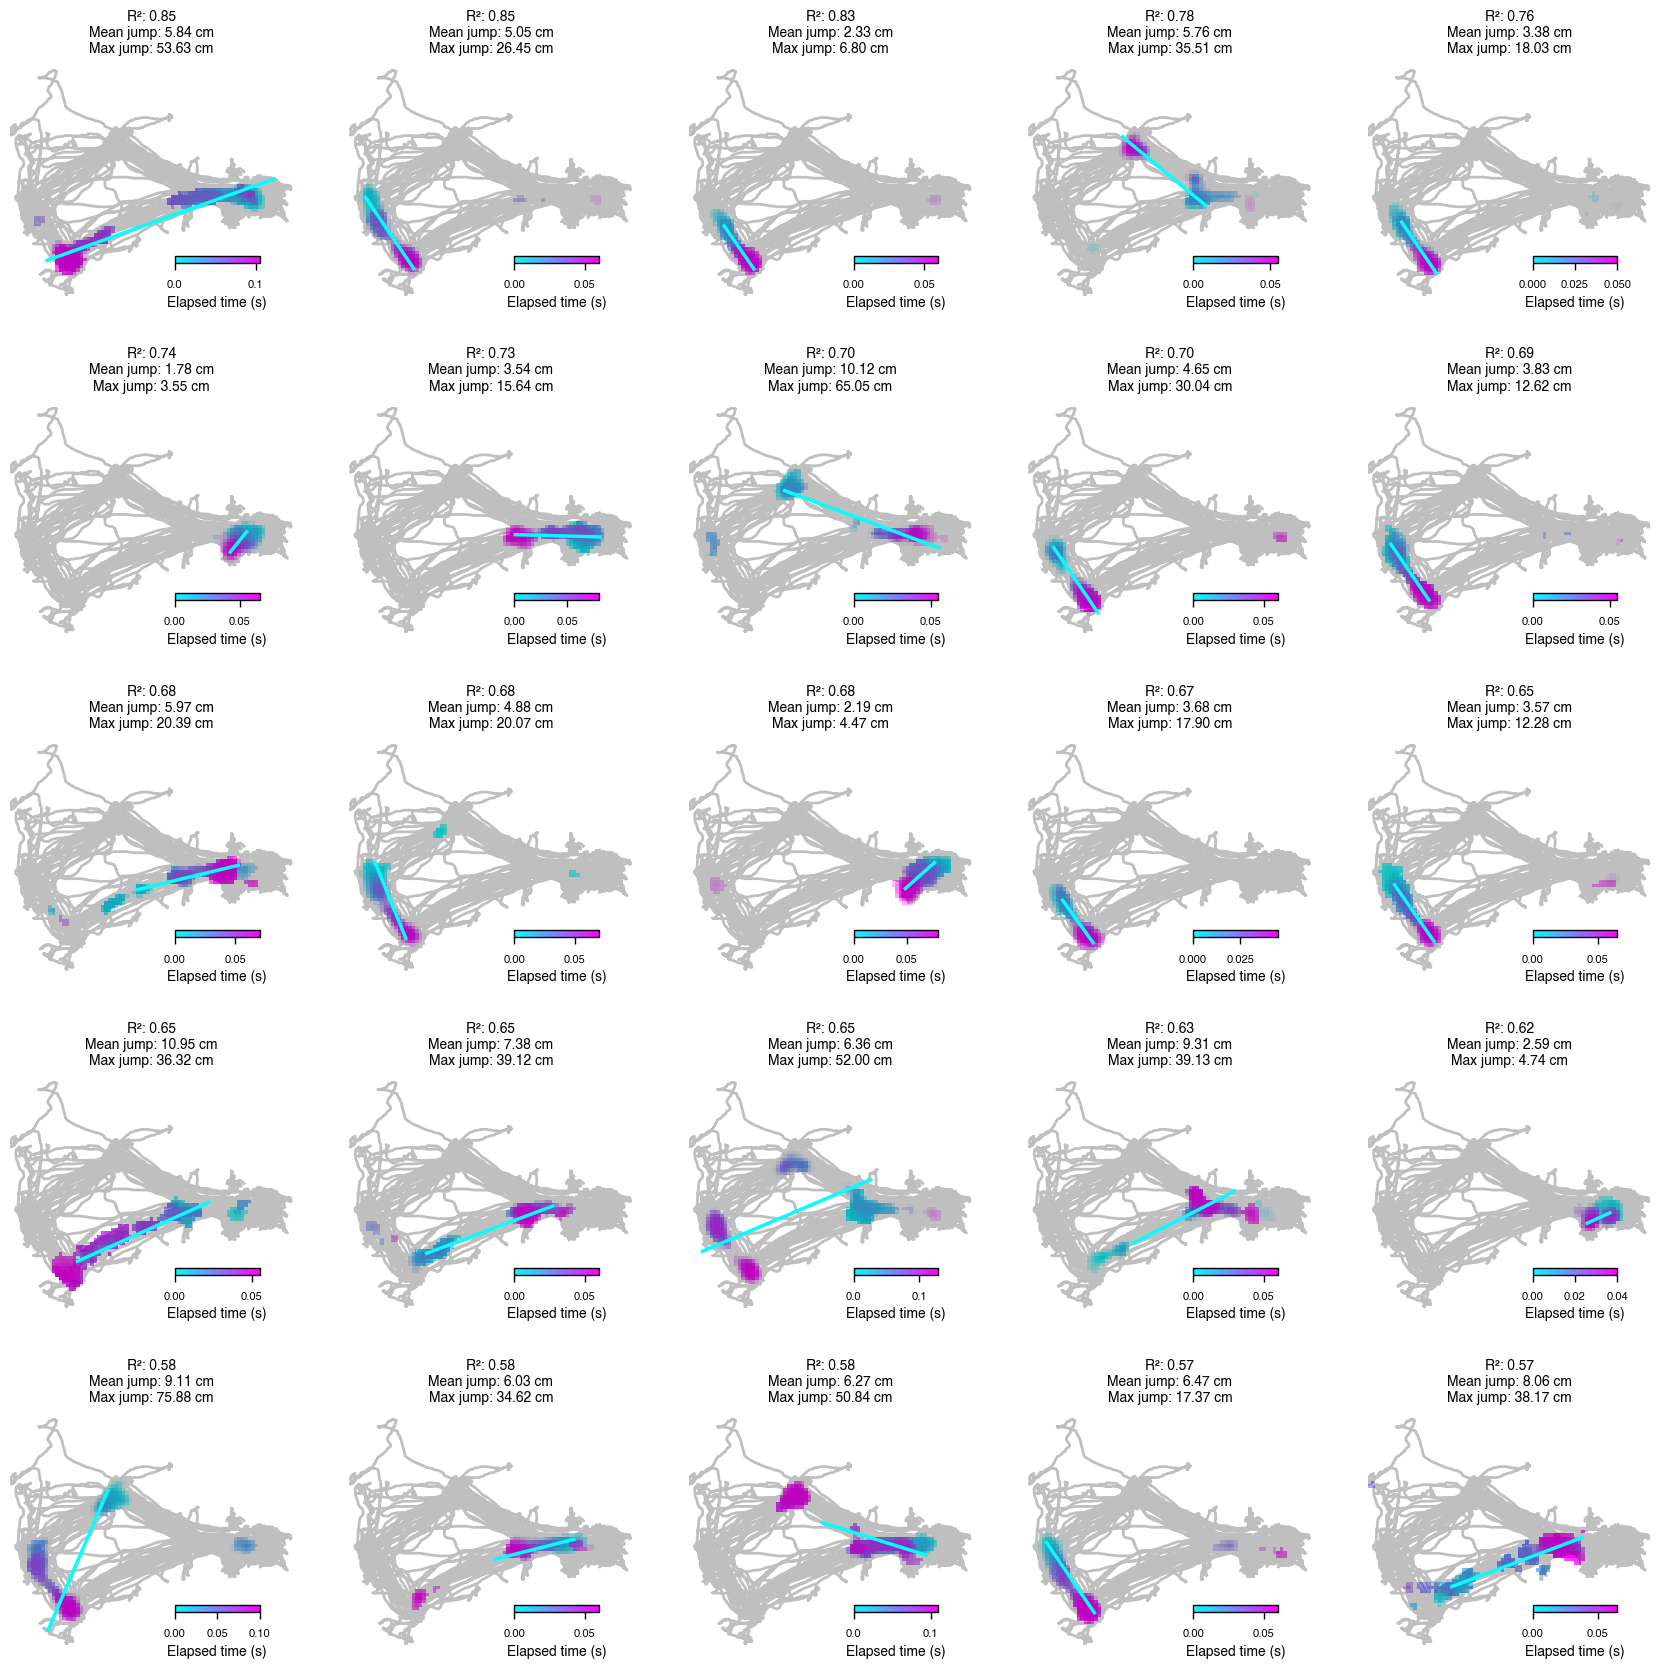

In [22]:
if RUN_REAL_DATA:
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    npy.plotting.set_plotting_defaults()

    x, y = pos[beh_epochs[TASK_EPOCH]].data

    fig, ax = plt.subplots(
        5,
        5,
        figsize=npy.plotting.set_size("nature_double", fraction=1.5, ratio=1),
        dpi=200,
    )
    ax = ax.flatten()
    # Ripple IDs are labels, not positions in the compact score arrays.
    results_by_ripple = potential_replays.set_index(
        "ripple_index", verify_integrity=True
    )
    ripple_index_potential = (
        potential_replays.query("jump < 12")
        .sort_values("regression_r2", ascending=False)
        .ripple_index.values
    )

    for i, rid in enumerate(ripple_index_potential[:25]):
        event = results_by_ripple.loc[rid]
        posterior_ripple = posterior_prob[:, :, ripple_index == rid]
        ax[i].plot(x, y, color="k", alpha=0.25, zorder=2)

        npy.plotting.plot_2d_replay(
            posterior_ripple,
            extent=[
                spatial_maps.bins[0][0],
                spatial_maps.bins[0][-1],
                spatial_maps.bins[1][0],
                spatial_maps.bins[1][-1],
            ],
            saturation=5,
            ax=ax[i],
        )

        # plot fit line
        t = np.arange(posterior_ripple.shape[2], dtype=float) * SLIDE_BY
        t_centered = t - t.mean()
        x_fit = event["mean_x"] + event["slope_x"] * t_centered
        y_fit = event["mean_y"] + event["slope_y"] * t_centered
        ax[i].plot(x_fit, y_fit, color="cyan", lw=1.25, zorder=4)

        ax[i].set_title(
            f"R²: {event['regression_r2']:.2f}\n"
            f"Mean jump: {event['jump']:.2f} cm\n"
            f"Max jump: {event['max_jump']:.2f} cm",
            fontsize=5,
        )

        # Colorbar
        cmap = matplotlib.colormaps.get_cmap("cool").resampled(posterior_prob.shape[2])
        norm = colors.Normalize(vmin=0, vmax=posterior_ripple.shape[2] * SLIDE_BY)
        sm = mpl_cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])

        cax = inset_axes(
            ax[i], width="30%", height="3%", loc="lower right", borderpad=2
        )
        cbar = plt.colorbar(sm, cax=cax, orientation="horizontal")
        cax.xaxis.set_label_position("bottom")
        cax.set_xlabel("Elapsed time (s)", fontsize=5, labelpad=2)
        cbar.ax.tick_params(labelsize=4)

        ax[i].axis("off")
    for unused_ax in ax[min(25, len(ripple_index_potential)) :]:
        unused_ax.set_visible(False)
    plt.show()

## Interpretation

| Scenario | R² | Interpretation |
|---|---|---|
| Perfect localized line, any direction | 1 | All spatial variance explained |
| Stationary diffuse posterior | 0 | No linear temporal movement |
| Stationary point mass | NaN | Total spatial variance is zero |
| Broader posterior, same moving mean | Lower | Uncertainty contributes residual variance |
| Time reversal | Unchanged | Slopes change sign |
| Curved or reversing path | Often lower | A single constant-velocity line is incomplete |
| Fragmented path | Can be substantial | R² alone does not establish continuity |

NaNs contribute zero weight. Keep original timestamps when removing time
bins; do not compress gaps. Negative and infinite weights are invalid.
R² is undefined for zero total weight or zero temporal or spatial variance.
Compare event R² against an upper-tail shuffle distribution to assess
significance. Selection of a suitable null is separate from regression fit.
